In [ ]:
import kagglehub

path = kagglehub.dataset_download("aayush9753/image-colorization-dataset")

print("Path to dataset files:", path)

100%|██████████| 473M/473M [00:04<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aayush9753/image-colorization-dataset/versions/1


In [ ]:
import glob
import random
import os
import numpy as np

import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
from torch import nn
from matplotlib import pyplot as plt


import argparse
import math
import itertools
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid

from torch.utils.data import DataLoader
from torch.autograd import Variable

import torch.nn as nn
import torch.nn.functional as F
import torch


from torchvision.models import vgg19

from skimage import color
from IPython import embed

In [ ]:
def load_img(img_path):
	out_np = np.asarray(Image.open(img_path))
	if(out_np.ndim==2):
		out_np = np.tile(out_np[:,:,None],3)
	return out_np

def resize_img(img, HW=(256,256), resample=3):
	return np.asarray(Image.fromarray(img).resize((HW[1],HW[0]), resample=resample))

def preprocess_img(img_rgb_orig, HW=(256,256), resample=3):
	img_rgb_rs = resize_img(img_rgb_orig, HW=HW, resample=resample)

	img_lab_orig = color.rgb2lab(img_rgb_orig)
	img_lab_rs = color.rgb2lab(img_rgb_rs)

	img_l_orig = img_lab_orig[:,:,0]
	img_l_rs = img_lab_rs[:,:,0]

	tens_orig_l = torch.Tensor(img_l_orig)[None,None,:,:]
	tens_rs_l = torch.Tensor(img_l_rs)[None,None,:,:]

	return (tens_orig_l, tens_rs_l)

def postprocess_tens_new(tens_orig_l, out_ab, mode='bilinear'):
    Batchsize = tens_orig_l.shape[0]

    output_ = []
    for i in range(Batchsize):
        tens_orig_l_i = tens_orig_l[i][np.newaxis, :, :, :]
        out_ab_i  = out_ab[i][np.newaxis, :, :, :]
        HW_orig_i = tens_orig_l_i.shape[2:]
        HW_i = out_ab_i.shape[2:]

        if(HW_orig_i[0]!=HW_i[0] or HW_orig_i[1]!=HW_i[1]):
            out_ab_orig_i = F.interpolate(out_ab_i, size=HW_orig_i, mode='bilinear')
        else:
            out_ab_orig_i = out_ab_i

        out_lab_orig_i = torch.cat((tens_orig_l_i, out_ab_orig_i), dim=1)
        output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))
    return np.array(output_)

In [ ]:
class BaseColor(nn.Module):
	def __init__(self):
		super(BaseColor, self).__init__()

		self.l_cent = 50.
		self.l_norm = 100.
		self.ab_norm = 110.

	def normalize_l(self, in_l):
		return (in_l-self.l_cent)/self.l_norm

	def unnormalize_l(self, in_l):
		return in_l*self.l_norm + self.l_cent

	def normalize_ab(self, in_ab):
		return in_ab/self.ab_norm

	def unnormalize_ab(self, in_ab):
		return in_ab*self.ab_norm


class ECCVGenerator(BaseColor):
    def __init__(self, norm_layer=nn.BatchNorm2d):
        super(ECCVGenerator, self).__init__()

        model1=[nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=True),]
        model1+=[nn.ReLU(True),]
        model1+=[nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=True),]
        model1+=[nn.ReLU(True),]
        model1+=[norm_layer(64),]

        model2=[nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=True),]
        model2+=[nn.ReLU(True),]
        model2+=[nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1, bias=True),]
        model2+=[nn.ReLU(True),]
        model2+=[norm_layer(128),]

        model3=[nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=True),]
        model3+=[nn.ReLU(True),]
        model3+=[nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),]
        model3+=[nn.ReLU(True),]
        model3+=[nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=True),]
        model3+=[nn.ReLU(True),]
        model3+=[norm_layer(256),]

        model4=[nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=True),]
        model4+=[nn.ReLU(True),]
        model4+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
        model4+=[nn.ReLU(True),]
        model4+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
        model4+=[nn.ReLU(True),]
        model4+=[norm_layer(512),]

        model5=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
        model5+=[nn.ReLU(True),]
        model5+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
        model5+=[nn.ReLU(True),]
        model5+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
        model5+=[nn.ReLU(True),]
        model5+=[norm_layer(512),]

        model6=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
        model6+=[nn.ReLU(True),]
        model6+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
        model6+=[nn.ReLU(True),]
        model6+=[nn.Conv2d(512, 512, kernel_size=3, dilation=2, stride=1, padding=2, bias=True),]
        model6+=[nn.ReLU(True),]
        model6+=[norm_layer(512),]

        model7=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
        model7+=[nn.ReLU(True),]
        model7+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
        model7+=[nn.ReLU(True),]
        model7+=[nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=True),]
        model7+=[nn.ReLU(True),]
        model7+=[norm_layer(512),]

        model8=[nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=True),]
        model8+=[nn.ReLU(True),]
        model8+=[nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),]
        model8+=[nn.ReLU(True),]
        model8+=[nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),]
        model8+=[nn.ReLU(True),]

        model8+=[nn.Conv2d(256, 313, kernel_size=1, stride=1, padding=0, bias=True),]

        self.model1 = nn.Sequential(*model1)
        self.model2 = nn.Sequential(*model2)
        self.model3 = nn.Sequential(*model3)
        self.model4 = nn.Sequential(*model4)
        self.model5 = nn.Sequential(*model5)
        self.model6 = nn.Sequential(*model6)
        self.model7 = nn.Sequential(*model7)
        self.model8 = nn.Sequential(*model8)

        self.softmax = nn.Softmax(dim=1)
        self.model_out = nn.Conv2d(313, 2, kernel_size=1, padding=0, dilation=1, stride=1, bias=False)
        self.upsample4 = nn.Upsample(scale_factor=4, mode='bilinear')

    def forward(self, input_l):
        conv1_2 = self.model1(self.normalize_l(input_l))
        conv2_2 = self.model2(conv1_2)
        conv3_3 = self.model3(conv2_2)
        conv4_3 = self.model4(conv3_3)
        conv5_3 = self.model5(conv4_3)
        conv6_3 = self.model6(conv5_3)
        conv7_3 = self.model7(conv6_3)
        conv8_3 = self.model8(conv7_3)
        out_reg = self.model_out(self.softmax(conv8_3))

        return self.unnormalize_ab(self.upsample4(out_reg))

def eccv16(pretrained=True):
	model = ECCVGenerator()
	if(pretrained):
		import torch.utils.model_zoo as model_zoo
		model.load_state_dict(model_zoo.load_url('https://colorizers.s3.us-east-2.amazonaws.com/colorization_release_v2-9b330a0b.pth',map_location='cpu',check_hash=True))
	return model

In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        vgg19_model = vgg19(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(vgg19_model.features.children())[:18])

    def forward(self, img):
        return self.feature_extractor(img)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()

        self.input_shape = input_shape
        in_channels, in_height, in_width = self.input_shape
        patch_h, patch_w = int(in_height / 2 ** 4), int(in_width / 2 ** 4)
        self.output_shape = (1, patch_h, patch_w)

        def discriminator_block(in_filters, out_filters, first_block=False):
            layers = []
            layers.append(nn.Conv2d(in_filters, out_filters, kernel_size=3, stride=1, padding=1))
            if not first_block:
                layers.append(nn.BatchNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            layers.append(nn.Conv2d(out_filters, out_filters, kernel_size=3, stride=2, padding=1))
            layers.append(nn.BatchNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        layers = []
        in_filters = in_channels
        for i, out_filters in enumerate([64, 128, 256, 512]):
            layers.extend(discriminator_block(in_filters, out_filters, first_block=(i == 0)))
            in_filters = out_filters

        layers.append(nn.Conv2d(out_filters, 1, kernel_size=3, stride=1, padding=1))

        self.model = nn.Sequential(*layers)

    def forward(self, img):
        return self.model(img)

In [ ]:
batch_size = 4
n_cpu = 0
out_channels = 3

class ImageDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform

        self.files = sorted(glob.glob(root + "/*.*"))

    def __getitem__(self, index):

        black_path = self.files[index % len(self.files)]
        color_path = black_path.replace('black','color')

        img_black = np.asarray(Image.open(black_path))
        if(img_black.ndim==2):
            img_black = np.tile(img_black[:,:,None],3)
        (tens_l_orig, tens_l_rs) = preprocess_img(img_black, HW=(400, 400))

        img_color = Image.open(color_path)
        img_color = self.transform(img_color)

        return {"black": tens_l_rs.squeeze(0), 'orig': tens_l_orig.squeeze(0), "color": img_color}


    def __len__(self):
        return len(self.files)

root = '/kaggle/input/image-colorization-dataset/data/train_black'
transform = transforms.Compose(
            [
                transforms.ToTensor(),
            ]
        )
dataloader = DataLoader(
    ImageDataset(root, transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=n_cpu,
)

torch.Size([400, 400, 1])


/tmp/ipython-input-1063368552.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  t[..., 0] = img[..., 0]


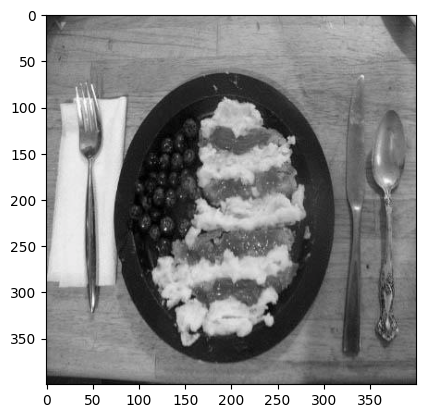

torch.Size([400, 400, 1])


/tmp/ipython-input-1063368552.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  t[..., 0] = img[..., 0]


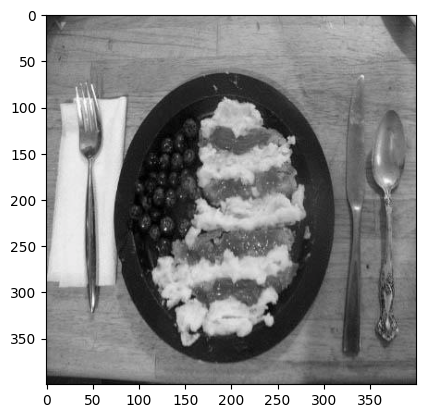

torch.Size([400, 400, 1])


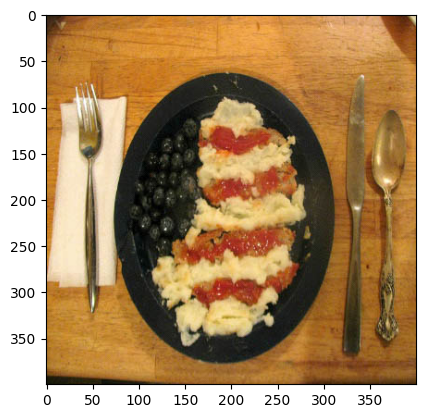

In [ ]:
dataiter = iter(dataloader)
data = next(dataiter)

i = 1
img = data['black'][i].permute(1, 2, 0)
print(img.shape)
t = np.zeros((400, 400, 3))
t[..., 0] = img[..., 0]
t = color.lab2rgb(t)
plt.imshow(t)
plt.show()

img = data['orig'][i].permute(1, 2, 0)
print(img.shape)
t = np.zeros((400, 400, 3))
t[..., 0] = img[..., 0]
t = color.lab2rgb(t)
plt.imshow(t)
plt.show()

print(img.shape)
img = data['color'][i].permute(1, 2, 0)
plt.imshow(img)
plt.show()

In [ ]:
class color_ecv(nn.Module):
    def __init__(self, in_channels):
        super(color_ecv, self).__init__()

        self.model = eccv16(pretrained=True)

    def forward(self, x):
        ecv_output = self.model(x)
        return ecv_output

In [ ]:
os.makedirs("colorit_gan/images", exist_ok=True)
os.makedirs("colorit_gan/saved_models", exist_ok=True)

In [ ]:
start_epoch = 0
n_epochs= 2

lr = 0.0002
b1 = 0.5
b2 = 0.999
decay_epoch = 4
in_channels = 1
out_channels = 3
sample_interval = 100
checkpoint_interval = 1

cuda = torch.cuda.is_available()

In [ ]:
shape = (400, 400)

generator = color_ecv(in_channels = 3)
discriminator = Discriminator(input_shape=(out_channels, *shape))
feature_extractor = FeatureExtractor()

feature_extractor.eval()

criterion_GAN = torch.nn.MSELoss()
criterion_content = torch.nn.L1Loss()

if cuda:
    generator = generator.cuda()
    discriminator = discriminator.cuda()
    feature_extractor = feature_extractor.cuda()
    criterion_GAN = criterion_GAN.cuda()
    criterion_content = criterion_content.cuda()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
if start_epoch != 0:
    generator.load_state_dict(torch.load("colorit_gan/saved_models/generator_"+str(start_epoch-1)+".pth"))
    discriminator.load_state_dict(torch.load("colorit_gan/saved_models/discriminator_"+str(start_epoch-1)+".pth"))

In [ ]:
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

Tensor = torch.cuda.FloatTensor if cuda else torch.Tensor

In [ ]:
if len(dataloader) == 0:
    print("No data found in the dataloader. Please check the dataset path.")
else:
    for epoch in range(start_epoch, n_epochs):
        for i, imgs in enumerate(dataloader):

            imgs_black = Variable(imgs["black"].type(Tensor))
            imgs_black_orig = Variable(imgs["orig"].type(Tensor))
            imgs_color = Variable(imgs["color"].type(Tensor))

            valid = Variable(Tensor(np.ones((imgs_black.size(0), *discriminator.output_shape))), requires_grad=False)
            fake = Variable(Tensor(np.zeros((imgs_black.size(0), *discriminator.output_shape))), requires_grad=False)

            optimizer_G.zero_grad()

            gen_ab = generator(imgs_black)
            gen_color = postprocess_tens_new(imgs_black_orig, gen_ab)
            if cuda:
                gen_color = torch.from_numpy(gen_color).to('cuda')

            loss_GAN = criterion_GAN(discriminator(gen_color), valid)

            gen_features = feature_extractor(gen_color.detach())
            real_features = feature_extractor(imgs_color.detach())
            loss_content = criterion_content(gen_features, real_features.detach())

            loss_G = loss_content + 1e-3 * loss_GAN

            loss_G.backward()
            optimizer_G.step()

            optimizer_D.zero_grad()

            loss_real = criterion_GAN(discriminator(imgs_color), valid)
            loss_fake = criterion_GAN(discriminator(gen_color.detach()), fake)

            loss_D = (loss_real + loss_fake) / 2

            loss_D.backward()
            optimizer_D.step()

            sys.stdout.write(
                "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
                % (epoch, n_epochs, i, len(dataloader), loss_D.item(), loss_G.item())
            )

            batches_done = epoch * len(dataloader) + i
            if batches_done % sample_interval == 0:
                #imgs_lr = nn.functional.interpolate(imgs_lr, scale_factor=4)
                gen_color = make_grid(gen_color.detach(), nrow=1, normalize=True)
                imgs_black_orig = make_grid(imgs_black_orig, nrow=1, normalize=True)
                img_grid = torch.cat((imgs_black_orig, gen_color), -1)
                save_image(img_grid, "./colorit_gan/images/%d.png" % batches_done, normalize=False)

        if checkpoint_interval != -1 and epoch % checkpoint_interval == 0:
            torch.save(generator.state_dict(), "./colorit_gan/saved_models/generator_%d.pth" % epoch)
            torch.save(discriminator.state_dict(), "./colorit_gan/saved_models/discriminator_%d.pth" % epoch)

/tmp/ipython-input-3314224708.py:11: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  valid = Variable(Tensor(np.ones((imgs_black.size(0), *discriminator.output_shape))), requires_grad=False)
/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))
/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 12 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))


[Epoch 0/2] [Batch 0/1250] [D loss: 0.888090] [G loss: 0.239276]

/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 20 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))


[Epoch 0/2] [Batch 1/1250] [D loss: 2.335853] [G loss: 0.216046]

/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 15 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))
/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))


...

[Epoch 1/2] [Batch 1227/1250] [D loss: 0.252958] [G loss: 0.250580][Epoch 1/2] [Batch 1228/1250] [D loss: 0.210575] [G loss: 0.236533][Epoch 1/2] [Batch 1229/1250] [D loss: 0.032318] [G loss: 0.155496][Epoch 1/2] [Batch 1230/1250] [D loss: 0.010701] [G loss: 0.227212][Epoch 1/2] [Batch 1231/1250] [D loss: 0.009196] [G loss: 0.159426][Epoch 1/2] [Batch 1232/1250] [D loss: 0.004261] [G loss: 0.235756][Epoch 1/2] [Batch 1233/1250] [D loss: 0.020209] [G loss: 0.200924][Epoch 1/2] [Batch 1234/1250] [D loss: 0.029467] [G loss: 0.270304]

/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 157 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))


[Epoch 1/2] [Batch 1235/1250] [D loss: 0.006108] [G loss: 0.188661]

/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 656 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))
/tmp/ipython-input-3329124963.py:40: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 148 negative Z values that have been clipped to zero
  output_.append(color.lab2rgb(out_lab_orig_i.data.cpu().numpy()[0,...].transpose((1,2,0))).transpose((2,0,1)))


[Epoch 1/2] [Batch 1236/1250] [D loss: 0.017407] [G loss: 0.281374][Epoch 1/2] [Batch 1237/1250] [D loss: 0.002924] [G loss: 0.182424][Epoch 1/2] [Batch 1238/1250] [D loss: 0.004137] [G loss: 0.201922][Epoch 1/2] [Batch 1239/1250] [D loss: 0.001923] [G loss: 0.157202][Epoch 1/2] [Batch 1240/1250] [D loss: 0.002082] [G loss: 0.174909][Epoch 1/2] [Batch 1241/1250] [D loss: 0.005141] [G loss: 0.264295][Epoch 1/2] [Batch 1242/1250] [D loss: 0.003225] [G loss: 0.209353][Epoch 1/2] [Batch 1243/1250] [D loss: 0.540387] [G loss: 0.277472][Epoch 1/2] [Batch 1244/1250] [D loss: 0.065342] [G loss: 0.213133][Epoch 1/2] [Batch 1245/1250] [D loss: 0.052561] [G loss: 0.255700][Epoch 1/2] [Batch 1246/1250] [D loss: 0.017417] [G loss: 0.213181][Epoch 1/2] [Batch 1247/1250] [D loss: 0.020335] [G loss: 0.243361][Epoch 1/2] [Batch 1248/1250] [D loss: 0.004716] [G loss: 0.203955][Epoch 1/2] [Batch 1249/1250] [D loss: 0.007606] [G loss: 0.224333]

In [ ]:
import gradio as gr
import torch
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = generator.to(device)
generator.eval()

def colorize_image(grayscale_image):
    img_np = np.asarray(grayscale_image.convert("RGB"))
    if img_np.ndim == 2:
        img_np = np.tile(img_np[:, :, None], 3)

    tens_l_orig, tens_l_rs = preprocess_img(img_np, HW=(400, 400))
    tens_l_rs = tens_l_rs.to(device)

    with torch.no_grad():
        gen_ab = generator(tens_l_rs)

    colorized_np = postprocess_tens_new(tens_l_orig.cpu(), gen_ab.cpu())

    colorized_img = Image.fromarray(
        (colorized_np[0].transpose((1, 2, 0)) * 255).clip(0, 255).astype(np.uint8)
    )

    return colorized_img


iface = gr.Interface(
    fn=colorize_image,
    inputs=gr.Image(label="Upload Grayscale Image", type="pil"),
    outputs=gr.Image(label="Display Colorized Image", type="pil"),
    title="Image Colorization Model Developed by MUDASSIR AHMED",
    description="Upload a grayscale image to see it colorized by the trained GAN model."
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c9de75c5d4a0b01cad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
